# Fuzzy Logic Mamdani & Sugeno — Movie Rating Prediction
## Implementasi *From Scratch* — 5 Variabel Input

**Variabel Input:**

| # | Variabel | Keterangan | Satuan |
|---|----------|-----------|--------|
| 1 | `budget` | Anggaran produksi | USD (juta) |
| 2 | `popularity` | Skor popularitas TMDb | Numerik |
| 3 | `runtime` | Durasi film | Menit |
| 4 | `vote_count` | Jumlah pemberi rating | Jumlah orang |
| 5 | `release_year` | Tahun rilis film | Tahun |

**Variabel Output:** `vote_average` — Rating Film (0–10)


## 1. Import Library

In [21]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/the-movies-dataset")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'the-movies-dataset' dataset.
Path to dataset files: /kaggle/input/the-movies-dataset


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.figsize': (14, 4), 'axes.grid': True, 'grid.alpha': 0.3})
print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)
print("Semua library siap.")


NumPy : 2.0.2
Pandas: 2.2.2
Semua library siap.


## 2. Eksplorasi & Pra-pemrosesan Data

In [23]:
import os
DATASET_PATH = 'movies_metadata.csv'
if not os.path.exists(DATASET_PATH):
    try:
        # Use path from the kagglehub download cell
        DATASET_PATH = os.path.join(path, "movies_metadata.csv")
    except NameError:
        DATASET_PATH = '/content/movies_metadata.csv'
        if not os.path.exists(DATASET_PATH):
            import kagglehub
            p = kagglehub.dataset_download("rounakbanik/the-movies-dataset")
            DATASET_PATH = os.path.join(p, "movies_metadata.csv")

df_raw = pd.read_csv(DATASET_PATH, low_memory=False)
print(f"Dataset mentah: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom")


Dataset mentah: 45,466 baris x 24 kolom


In [24]:
# Konversi & ekstrak kolom yang dibutuhkan
df = df_raw.copy()
df['budget']       = pd.to_numeric(df['budget'],       errors='coerce')
df['popularity']   = pd.to_numeric(df['popularity'],   errors='coerce')
df['runtime']      = pd.to_numeric(df['runtime'],      errors='coerce')
df['vote_count']   = pd.to_numeric(df['vote_count'],   errors='coerce')
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')

# Ekstrak tahun dari release_date
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year

COLS = ['budget','popularity','runtime','vote_count','release_year','vote_average']
df = df[COLS].dropna()
df = df[
    (df['budget']       > 0) &
    (df['popularity']   > 0) &
    (df['runtime']      > 0) &
    (df['vote_count']   > 0) &
    (df['release_year'] > 1900) &
    (df['vote_average'] > 0)
]

# Filter outlier dengan IQR per variabel input
def remove_outliers(df, col, lo=0.01, hi=0.99):
    a, b = df[col].quantile(lo), df[col].quantile(hi)
    return df[(df[col] >= a) & (df[col] <= b)]

for col in ['budget','popularity','runtime','vote_count']:
    df = remove_outliers(df, col)

# Konversi budget ke juta USD
df['budget_M'] = df['budget'] / 1e6
df = df.reset_index(drop=True)

print(f"Dataset bersih: {len(df):,} baris")
print()
print(df[['budget_M','popularity','runtime','vote_count','release_year','vote_average']].describe().round(2))


Dataset bersih: 8,094 baris

       budget_M  popularity   runtime  vote_count  release_year  vote_average
count 8094.0000   8094.0000 8094.0000   8094.0000     8094.0000     8094.0000
mean    19.8100      6.7600  105.4000    363.7500     1999.6000        6.0500
std     27.7200      4.7800   19.1800    624.8100       16.8900        1.0300
min      0.0000      0.0900   55.0000      2.0000     1914.0000        0.7000
25%      2.2700      2.4900   92.0000     24.0000     1994.0000        5.5000
50%      9.0000      6.4900  101.0000    101.0000     2005.0000        6.1000
75%     25.0000      9.8900  115.0000    394.0000     2011.0000        6.8000
max    175.0000     29.1300  182.0000   4172.0000     2017.0000       10.0000


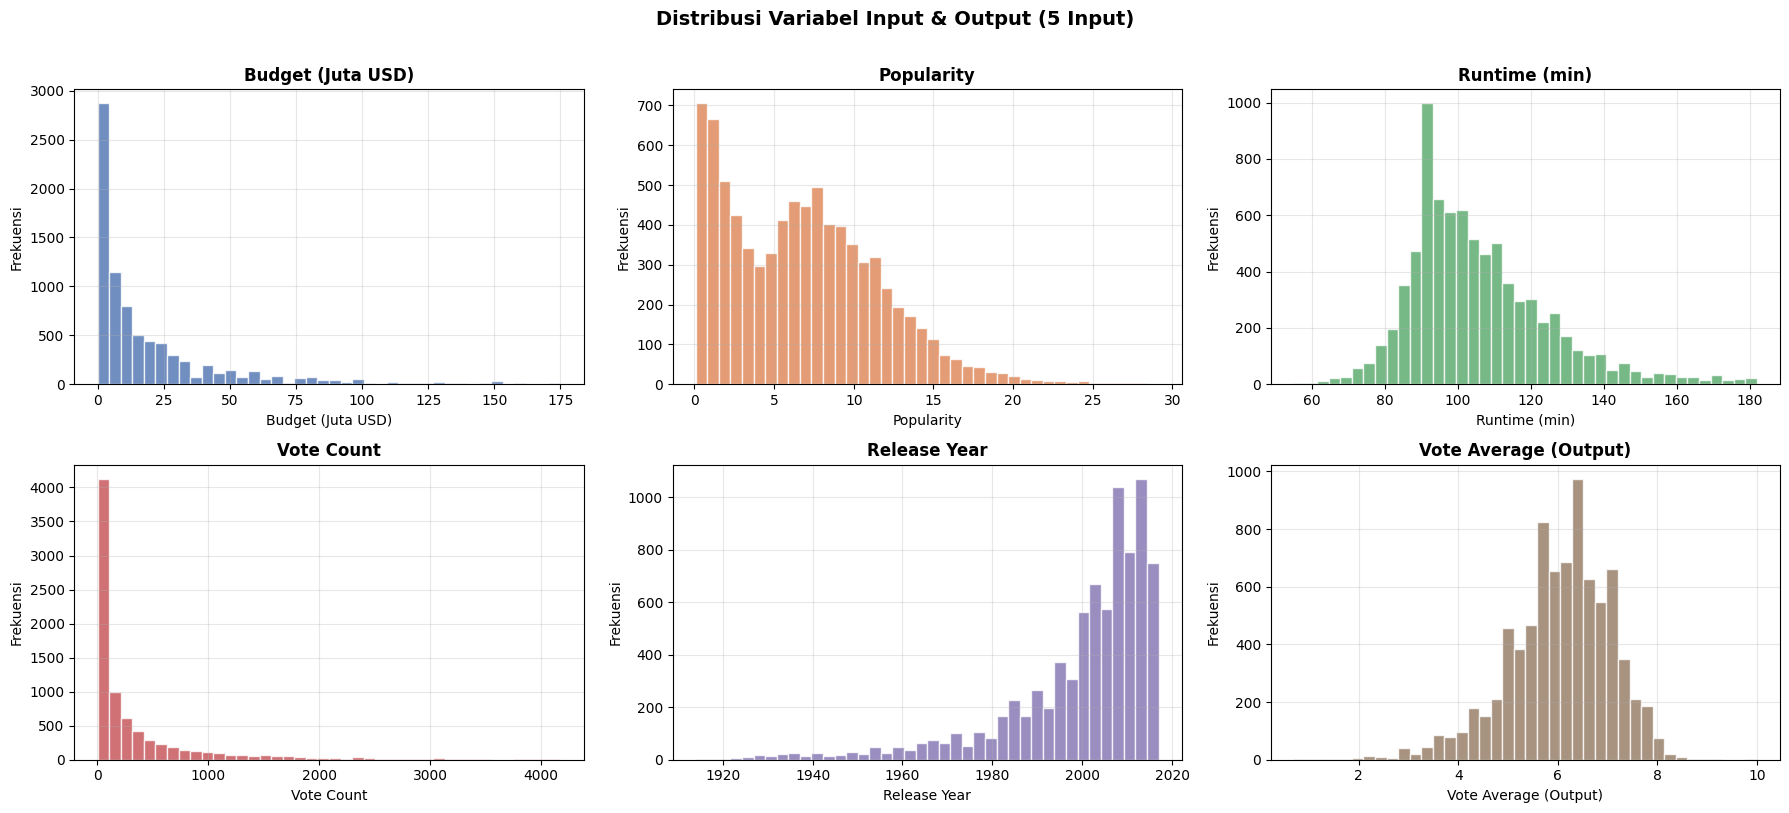

In [25]:
# Visualisasi distribusi semua variabel
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
features = ['budget_M','popularity','runtime','vote_count','release_year','vote_average']
labels   = ['Budget (Juta USD)','Popularity','Runtime (min)','Vote Count','Release Year','Vote Average (Output)']
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2','#937860']

for ax, feat, lab, col in zip(axes.flat, features, labels, colors):
    ax.hist(df[feat], bins=40, color=col, alpha=0.8, edgecolor='white')
    ax.set_title(lab, fontweight='bold')
    ax.set_xlabel(lab); ax.set_ylabel('Frekuensi')

plt.suptitle('Distribusi Variabel Input & Output (5 Input)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('distributions_v2.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Fungsi Keanggotaan (Membership Functions)

### Formulasi Matematis

**Triangular:** $\mu(x) = \max(0, \min(\frac{x-a}{b-a}, \frac{c-x}{c-b}))$

**Trapezoidal:** $\mu(x) = \max(0, \min(\frac{x-a}{b-a}, 1, \frac{d-x}{d-c}))$


In [26]:
# ================================================================
#  FUNGSI KEANGGOTAAN — FROM SCRATCH
# ================================================================

def trimf(x, a, b, c):
    """Triangular MF: puncak di b, nol di a dan c"""
    left  = (x - a) / (b - a) if b != a else (1.0 if x >= a else 0.0)
    right = (c - x) / (c - b) if c != b else (1.0 if x <= c else 0.0)
    return float(max(0.0, min(left, right)))

def trapmf(x, a, b, c, d):
    """Trapezoidal MF: plateau antara b dan c"""
    left  = (x - a) / (b - a) if b != a else (1.0 if x >= b else 0.0)
    right = (d - x) / (d - c) if d != c else (1.0 if x <= c else 0.0)
    return float(max(0.0, min(left, 1.0, right)))

# ── INPUT 1: Budget (juta USD) ─────────────────────────────
# Range efektif: 0 – 175 juta  | P25=2.3, P50=9, P75=25
def mf_budget_low(x):    return trapmf(x, 0,  0,  3,  10)
def mf_budget_medium(x): return trimf(x,  5,  20, 50)
def mf_budget_high(x):   return trapmf(x, 40, 80, 175, 175)

# ── INPUT 2: Popularity ─────────────────────────────────────
# Range efektif: 0 – 29  | P25=2.5, P50=6.5, P75=9.9
def mf_pop_low(x):    return trapmf(x, 0,  0,  2,  5)
def mf_pop_medium(x): return trimf(x,  3,  8,  15)
def mf_pop_high(x):   return trapmf(x, 12, 20, 29, 29)

# ── INPUT 3: Runtime (menit) ────────────────────────────────
# Range efektif: 45 – 200 menit | P25=92, P50=101, P75=116
def mf_rt_short(x):  return trapmf(x, 45,  45,  75,  90)
def mf_rt_medium(x): return trimf(x,  80,  105, 130)
def mf_rt_long(x):   return trapmf(x, 120, 150, 200, 200)

# ── INPUT 4: Vote Count ─────────────────────────────────────
# Range efektif: 1 – 2000  | P25=24, P50=101, P75=394
# Semakin banyak vote -> rating lebih representatif
def mf_vc_low(x):    return trapmf(x, 0,   0,   50,  150)
def mf_vc_medium(x): return trimf(x,  100, 400, 1000)
def mf_vc_high(x):   return trapmf(x, 700, 1500, 2000, 2000)

# ── INPUT 5: Release Year ───────────────────────────────────
# Range: 1914 – 2017  | P25=1994, P50=2005, P75=2011
# Old: klasik tersaring | Mid: era transisi | Recent: modern
def mf_yr_old(x):    return trapmf(x, 1914, 1914, 1980, 1995)
def mf_yr_mid(x):    return trimf(x,  1985, 2000, 2010)
def mf_yr_recent(x): return trapmf(x, 2005, 2012, 2017, 2017)

# ── OUTPUT: Vote Average (0–10) ─────────────────────────────
OUTPUT_UNIVERSE = np.linspace(0, 10, 500)
def mf_rating_low(x):    return trapmf(x, 0,   0,   3.5, 5.5)
def mf_rating_medium(x): return trimf(x,  4.5, 6.0, 7.5)
def mf_rating_high(x):   return trapmf(x, 6.5, 8.0, 10,  10)

OUTPUT_MF    = {'low': mf_rating_low, 'medium': mf_rating_medium, 'high': mf_rating_high}
SUGENO_CONST = {'low': 3.5, 'medium': 6.0, 'high': 8.0}

print("Fungsi keanggotaan berhasil didefinisikan:")
print("  budget     : Low, Medium, High")
print("  popularity : Low, Medium, High")
print("  runtime    : Short, Medium, Long")
print("  vote_count : Low, Medium, High")
print("  release_year: Old, Mid, Recent")
print("  output     : Low, Medium, High")


Fungsi keanggotaan berhasil didefinisikan:
  budget     : Low, Medium, High
  popularity : Low, Medium, High
  runtime    : Short, Medium, Long
  vote_count : Low, Medium, High
  release_year: Old, Mid, Recent
  output     : Low, Medium, High


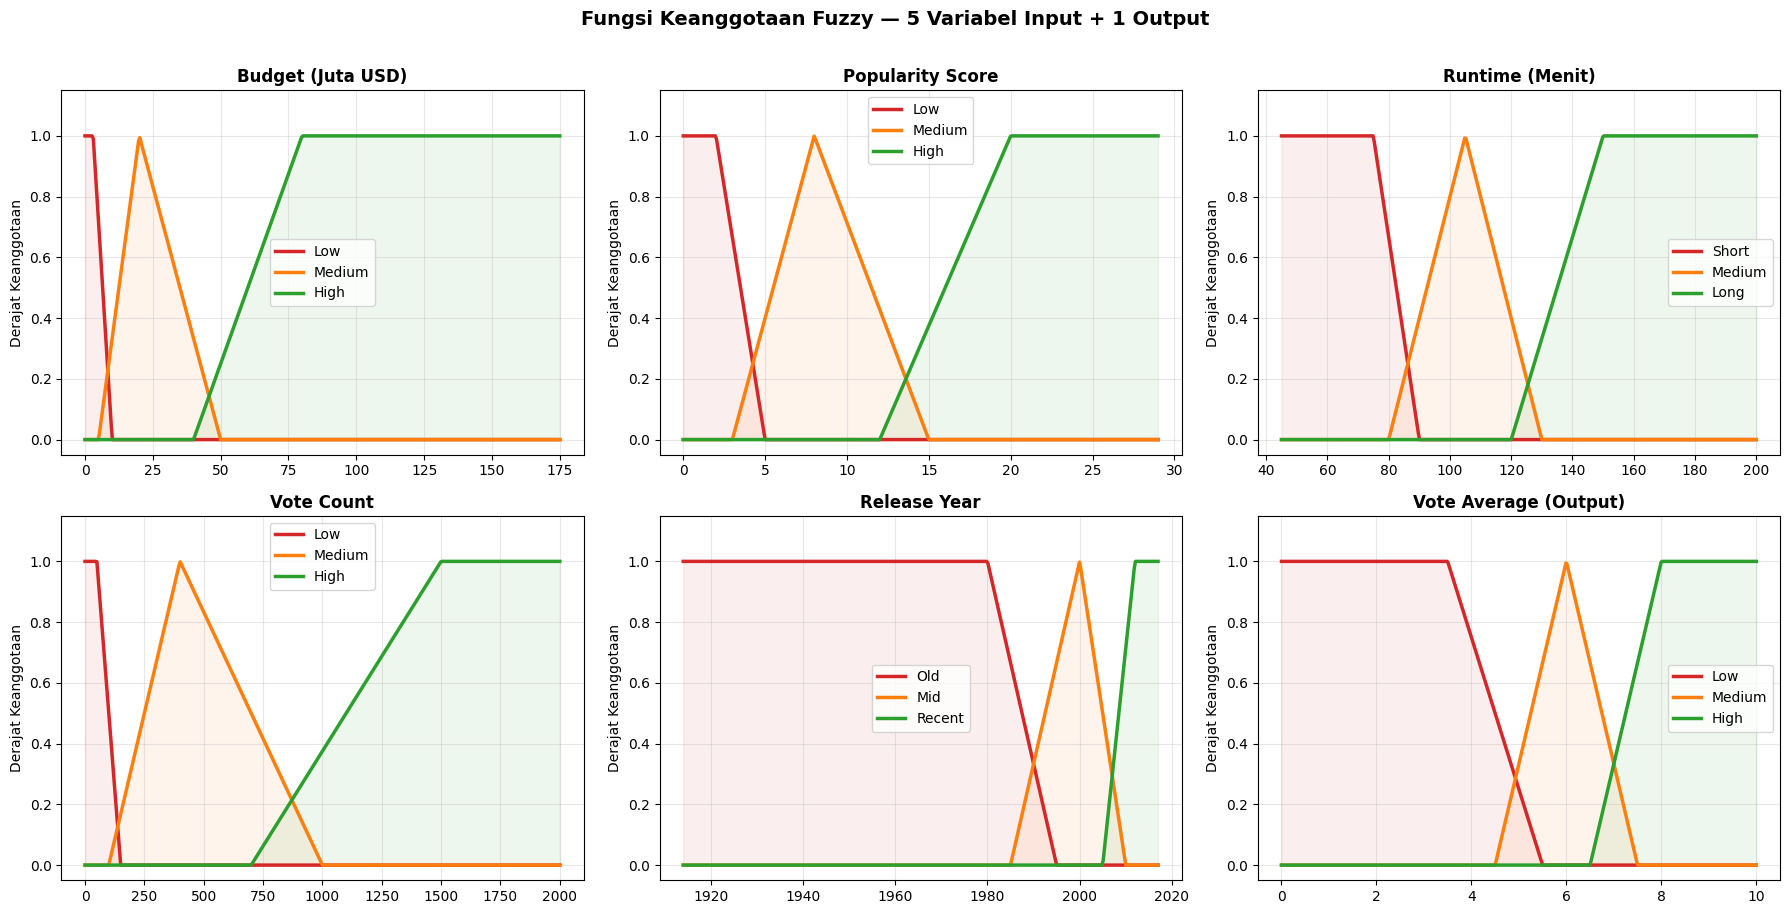

In [27]:
# Visualisasi semua fungsi keanggotaan
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
C = ['#D62728','#FF7F0E','#2CA02C']

mf_configs = [
    ('Budget (Juta USD)',   np.linspace(0, 175, 400),
     [mf_budget_low, mf_budget_medium, mf_budget_high], ['Low','Medium','High']),
    ('Popularity Score',    np.linspace(0, 29, 400),
     [mf_pop_low, mf_pop_medium, mf_pop_high], ['Low','Medium','High']),
    ('Runtime (Menit)',     np.linspace(45, 200, 400),
     [mf_rt_short, mf_rt_medium, mf_rt_long], ['Short','Medium','Long']),
    ('Vote Count',          np.linspace(0, 2000, 400),
     [mf_vc_low, mf_vc_medium, mf_vc_high], ['Low','Medium','High']),
    ('Release Year',        np.linspace(1914, 2017, 400),
     [mf_yr_old, mf_yr_mid, mf_yr_recent], ['Old','Mid','Recent']),
    ('Vote Average (Output)', OUTPUT_UNIVERSE,
     [mf_rating_low, mf_rating_medium, mf_rating_high], ['Low','Medium','High']),
]

for ax, (title, uni, mfs, lbls) in zip(axes.flat, mf_configs):
    for mf, c, lbl in zip(mfs, C, lbls):
        vals = [mf(x) for x in uni]
        ax.plot(uni, vals, color=c, lw=2.5, label=lbl)
        ax.fill_between(uni, vals, alpha=0.08, color=c)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Derajat Keanggotaan'); ax.set_ylim(-0.05, 1.15)
    ax.legend()

plt.suptitle('Fungsi Keanggotaan Fuzzy — 5 Variabel Input + 1 Output',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('membership_v2.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Rule Base — 27 Aturan IF-THEN

Dengan 5 variabel input, rule base diperluas menjadi **27 aturan** yang mencakup kombinasi
paling penting secara domain. Dua variabel baru (`vote_count` dan `release_year`) bertindak
sebagai **modifier** yang memperkuat atau memperlemah rating:

- `vote_count` **Low** → rating tidak bisa dipercaya (cenderung turunkan keyakinan)
- `vote_count` **High** → rating representatif (perkuat keyakinan)
- `release_year` **Old** → film klasik yang masih ada = tersaring kualitasnya (*survivorship bias*)
- `release_year` **Recent** → film modern, lebih bervariasi


In [28]:
# ================================================================
#  RULE BASE — 27 ATURAN IF-THEN (5 variabel input)
#  Format: (budget_mf, pop_mf, rt_mf, vc_mf, yr_mf, output_label)
#
#  Struktur: budget x popularity x runtime (3x3x3 core = 27 rules)
#  vote_count & release_year sebagai modifier pada setiap rule
# ================================================================

RULES = [
    # ── Budget LOW ─────────────────────────────────────────────────────────
    # R1:  Indie kecil, tidak dikenal, pendek, sedikit vote → rating rendah
    (mf_budget_low, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_recent, 'low'),
    # R2:  Indie, popularitas rendah, durasi normal → rating sedang
    (mf_budget_low, mf_pop_low,    mf_rt_medium, mf_vc_medium, mf_yr_mid,    'medium'),
    # R3:  Indie, populer sedang, durasi normal → rating sedang
    (mf_budget_low, mf_pop_medium, mf_rt_medium, mf_vc_medium, mf_yr_recent, 'medium'),
    # R4:  Indie, populer sedang, panjang → sedang (terlalu panjang)
    (mf_budget_low, mf_pop_medium, mf_rt_long,   mf_vc_low,    mf_yr_recent, 'medium'),
    # R5:  Indie viral, vote banyak → rating tinggi (cult classic modern)
    (mf_budget_low, mf_pop_high,   mf_rt_medium, mf_vc_high,   mf_yr_recent, 'high'),
    # R6:  Indie lama, vote tinggi → klasik tersaring → rating tinggi
    (mf_budget_low, mf_pop_medium, mf_rt_medium, mf_vc_high,   mf_yr_old,    'high'),
    # R7:  Indie lama, dikenal banyak → cult classic → tinggi
    (mf_budget_low, mf_pop_high,   mf_rt_medium, mf_vc_medium, mf_yr_old,    'high'),
    # R8:  Indie kecil, vote sedikit, film lama → rendah (terlupakan)
    (mf_budget_low, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_old,    'low'),
    # R9:  Indie, populer tinggi, vote sedang, era mid → sedang
    (mf_budget_low, mf_pop_high,   mf_rt_long,   mf_vc_medium, mf_yr_mid,    'medium'),

    # ── Budget MEDIUM ──────────────────────────────────────────────────────
    # R10: Budget sedang, tidak dikenal, pendek → rendah
    (mf_budget_medium, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_recent, 'low'),
    # R11: Budget sedang, popularitas rendah, durasi normal → sedang
    (mf_budget_medium, mf_pop_low,    mf_rt_medium, mf_vc_medium, mf_yr_mid,    'medium'),
    # R12: Budget sedang, popularitas sedang, pendek → sedang
    (mf_budget_medium, mf_pop_medium, mf_rt_short,  mf_vc_medium, mf_yr_recent, 'medium'),
    # R13: Sweet spot — budget/pop/runtime ideal, vote banyak → tinggi
    (mf_budget_medium, mf_pop_medium, mf_rt_medium, mf_vc_high,   mf_yr_recent, 'high'),
    # R14: Budget sedang, pop sedang, panjang → sedang
    (mf_budget_medium, mf_pop_medium, mf_rt_long,   mf_vc_medium, mf_yr_recent, 'medium'),
    # R15: Budget sedang, populer tinggi, vote banyak → tinggi
    (mf_budget_medium, mf_pop_high,   mf_rt_medium, mf_vc_high,   mf_yr_recent, 'high'),
    # R16: Budget sedang, film lama, vote tinggi → klasik berkualitas
    (mf_budget_medium, mf_pop_medium, mf_rt_medium, mf_vc_high,   mf_yr_old,    'high'),
    # R17: Budget sedang, pop rendah, vote sedikit → rendah
    (mf_budget_medium, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_old,    'low'),
    # R18: Budget sedang, pop tinggi, vote sedang, era mid → sedang-tinggi
    (mf_budget_medium, mf_pop_high,   mf_rt_medium, mf_vc_medium, mf_yr_mid,    'medium'),

    # ── Budget HIGH ────────────────────────────────────────────────────────
    # R19: Big budget, tidak populer, pendek, vote sedikit → rendah (flop)
    (mf_budget_high, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_recent, 'low'),
    # R20: Blockbuster mediocre, vote sedang → sedang
    (mf_budget_high, mf_pop_low,    mf_rt_medium, mf_vc_medium, mf_yr_recent, 'medium'),
    # R21: Blockbuster mainstream → sedang
    (mf_budget_high, mf_pop_medium, mf_rt_medium, mf_vc_medium, mf_yr_recent, 'medium'),
    # R22: Blockbuster sukses, vote banyak → tinggi
    (mf_budget_high, mf_pop_high,   mf_rt_medium, mf_vc_high,   mf_yr_recent, 'high'),
    # R23: Big budget lama, vote tinggi → klasik blockbuster
    (mf_budget_high, mf_pop_high,   mf_rt_medium, mf_vc_high,   mf_yr_old,    'high'),
    # R24: Blockbuster panjang, vote banyak → sedang (terlalu panjang)
    (mf_budget_high, mf_pop_high,   mf_rt_long,   mf_vc_high,   mf_yr_recent, 'medium'),
    # R25: Big budget, tidak populer, vote sedikit, lama → rendah
    (mf_budget_high, mf_pop_low,    mf_rt_short,  mf_vc_low,    mf_yr_old,    'low'),
    # R26: Blockbuster era mid, pop sedang, vote sedang → sedang
    (mf_budget_high, mf_pop_medium, mf_rt_medium, mf_vc_medium, mf_yr_mid,    'medium'),
    # R27: Blockbuster era mid, populer tinggi, vote tinggi → tinggi
    (mf_budget_high, mf_pop_high,   mf_rt_medium, mf_vc_high,   mf_yr_mid,    'high'),
]

# Mapping fungsi MF -> label (karena fungsi MF tidak punya docstring)
_LABEL_MAP = {
    mf_budget_low: 'low', mf_budget_medium: 'medium', mf_budget_high: 'high',
    mf_pop_low: 'low', mf_pop_medium: 'medium', mf_pop_high: 'high',
    mf_rt_short: 'short', mf_rt_medium: 'medium', mf_rt_long: 'long',
    mf_vc_low: 'low', mf_vc_medium: 'medium', mf_vc_high: 'high',
    mf_yr_old: 'old', mf_yr_mid: 'mid', mf_yr_recent: 'recent',
}

print(f"Rule base berhasil didefinisikan: {len(RULES)} aturan")
print()
for i, (bf, pf, rf, vcf, yrf, cons) in enumerate(RULES, 1):
    bl = _LABEL_MAP[bf]
    pl = _LABEL_MAP[pf]
    rl = _LABEL_MAP[rf]
    vl = _LABEL_MAP[vcf]
    yl = _LABEL_MAP[yrf]
    print(f"  R{i:02d}: IF Budget={bl:6s} Pop={pl:6s} RT={rl:6s} VC={vl:6s} YR={yl:6s} => {cons.upper()}")

Rule base berhasil didefinisikan: 27 aturan

  R01: IF Budget=low    Pop=low    RT=short  VC=low    YR=recent => LOW
  R02: IF Budget=low    Pop=low    RT=medium VC=medium YR=mid    => MEDIUM
  R03: IF Budget=low    Pop=medium RT=medium VC=medium YR=recent => MEDIUM
  R04: IF Budget=low    Pop=medium RT=long   VC=low    YR=recent => MEDIUM
  R05: IF Budget=low    Pop=high   RT=medium VC=high   YR=recent => HIGH
  R06: IF Budget=low    Pop=medium RT=medium VC=high   YR=old    => HIGH
  R07: IF Budget=low    Pop=high   RT=medium VC=medium YR=old    => HIGH
  R08: IF Budget=low    Pop=low    RT=short  VC=low    YR=old    => LOW
  R09: IF Budget=low    Pop=high   RT=long   VC=medium YR=mid    => MEDIUM
  R10: IF Budget=medium Pop=low    RT=short  VC=low    YR=recent => LOW
  R11: IF Budget=medium Pop=low    RT=medium VC=medium YR=mid    => MEDIUM
  R12: IF Budget=medium Pop=medium RT=short  VC=medium YR=recent => MEDIUM
  R13: IF Budget=medium Pop=medium RT=medium VC=high   YR=recent => HI

## 5. Fuzzifikasi

In [29]:
# ================================================================
#  HELPER: ekstrak label dari docstring fungsi MF
# ================================================================

def _label(mf):
    doc = mf.__doc__.split()[0].lower()
    if 'triangular' in doc or 'trapezoidal' in doc:
        # fallback: parse nama fungsi
        name = mf.__name__
        if 'low' in name or 'short' in name or 'old' in name:
            return name.split('_')[-1]
        return name.split('_')[-1]
    return doc

# Peta fungsi ke label (lebih robust)
BUD_MAP = {mf_budget_low:'low',    mf_budget_medium:'medium', mf_budget_high:'high'}
POP_MAP = {mf_pop_low:'low',       mf_pop_medium:'medium',    mf_pop_high:'high'}
RT_MAP  = {mf_rt_short:'short',    mf_rt_medium:'medium',     mf_rt_long:'long'}
VC_MAP  = {mf_vc_low:'low',        mf_vc_medium:'medium',     mf_vc_high:'high'}
YR_MAP  = {mf_yr_old:'old',        mf_yr_mid:'mid',           mf_yr_recent:'recent'}

def fuzzify(budget_M, popularity, runtime, vote_count, release_year):
    """
    Fuzzifikasi 5 variabel input sekaligus.
    Return: dict {variabel: {label: derajat_keanggotaan}}
    """
    return {
        'budget':      {'low': mf_budget_low(budget_M),  'medium': mf_budget_medium(budget_M),  'high': mf_budget_high(budget_M)},
        'popularity':  {'low': mf_pop_low(popularity),   'medium': mf_pop_medium(popularity),   'high': mf_pop_high(popularity)},
        'runtime':     {'short': mf_rt_short(runtime),   'medium': mf_rt_medium(runtime),       'long': mf_rt_long(runtime)},
        'vote_count':  {'low': mf_vc_low(vote_count),    'medium': mf_vc_medium(vote_count),    'high': mf_vc_high(vote_count)},
        'release_year':{'old': mf_yr_old(release_year),  'mid': mf_yr_mid(release_year),        'recent': mf_yr_recent(release_year)},
    }

# Contoh fuzzifikasi
ex = dict(budget_M=15.0, popularity=8.0, runtime=105.0, vote_count=350.0, release_year=2010)
fz = fuzzify(**ex)

print("Contoh Fuzzifikasi:")
print(f"  Input: Budget=${ex['budget_M']}M | Pop={ex['popularity']} | RT={ex['runtime']}min | VC={ex['vote_count']} | Year={ex['release_year']}")
print()
for var, sets in fz.items():
    vals = '  '.join([f"{lbl}={v:.4f}" for lbl, v in sets.items()])
    print(f"  {var:13s}: {vals}")


Contoh Fuzzifikasi:
  Input: Budget=$15.0M | Pop=8.0 | RT=105.0min | VC=350.0 | Year=2010

  budget       : low=0.0000  medium=0.6667  high=0.0000
  popularity   : low=0.0000  medium=1.0000  high=0.0000
  runtime      : short=0.0000  medium=1.0000  long=0.0000
  vote_count   : low=0.0000  medium=0.8333  high=0.0000
  release_year : old=0.0000  mid=0.0000  recent=0.7143


## 6. Sistem Inferensi Mamdani

Alur: **Fuzzifikasi → Implikasi Min (AND) → Agregasi Max → Defuzzifikasi Centroid**


In [30]:
# ================================================================
#  MAMDANI INFERENCE - FROM SCRATCH (5 variabel input)
# ================================================================

def trapz_safe(y, x):
    if hasattr(np, 'trapezoid'):
        return np.trapezoid(y, x)
    else:
        return np.trapz(y, x)

def mamdani_infer(budget_M, popularity, runtime, vote_count, release_year):
    """
    Mamdani FIS dengan 5 input dan 27 rule.
    Implikasi : Min  | Agregasi: Max | Defuzz: Centroid (COA)
    """
    fuzz = fuzzify(budget_M, popularity, runtime, vote_count, release_year)
    agg  = np.zeros(len(OUTPUT_UNIVERSE))

    for (bf, pf, rf, vcf, yrf, cons) in RULES:
        mu_b  = fuzz['budget'     ][BUD_MAP[bf]]
        mu_p  = fuzz['popularity' ][POP_MAP[pf]]
        mu_r  = fuzz['runtime'    ][RT_MAP[rf]]
        mu_vc = fuzz['vote_count' ][VC_MAP[vcf]]
        mu_yr = fuzz['release_year'][YR_MAP[yrf]]

        # Firing strength: AND = min semua antecedent
        alpha = min(mu_b, mu_p, mu_r, mu_vc, mu_yr)

        if alpha == 0:
            continue

        # Klip consequent MF pada alpha, lalu agregasi (max)
        clipped = np.array([min(alpha, OUTPUT_MF[cons](y)) for y in OUTPUT_UNIVERSE])
        agg     = np.maximum(agg, clipped)

    # Defuzzifikasi Centroid
    num = trapz_safe(OUTPUT_UNIVERSE * agg, OUTPUT_UNIVERSE)
    den = trapz_safe(agg, OUTPUT_UNIVERSE)
    return num / den if den > 1e-10 else 5.0

# Uji single inference
m_ex = mamdani_infer(**ex)
print(f"Mamdani Inference:")
print(f"  Input : Budget=${ex['budget_M']}M | Pop={ex['popularity']} | RT={ex['runtime']}min | VC={ex['vote_count']} | Year={ex['release_year']}")
print(f"  Output: vote_average = {m_ex:.4f}")


Mamdani Inference:
  Input : Budget=$15.0M | Pop=8.0 | RT=105.0min | VC=350.0 | Year=2010
  Output: vote_average = 5.0000


## 7. Sistem Inferensi Sugeno

Alur: **Fuzzifikasi → Firing Strength Min → Weighted Average**

| Consequent | Nilai Konstan |
|------------|--------------|
| Low        | 3.5          |
| Medium     | 6.0          |
| High       | 8.0          |


In [31]:
# ================================================================
#  SUGENO INFERENCE — FROM SCRATCH (5 variabel input)
# ================================================================

def sugeno_infer(budget_M, popularity, runtime, vote_count, release_year):
    """
    Sugeno Zero-Order FIS dengan 5 input dan 27 rule.
    Defuzzifikasi: Weighted Average  x* = SUM(alpha_i * z_i) / SUM(alpha_i)
    """
    fuzz = fuzzify(budget_M, popularity, runtime, vote_count, release_year)
    numerator, denominator = 0.0, 0.0

    for (bf, pf, rf, vcf, yrf, cons) in RULES:
        mu_b  = fuzz['budget'     ][BUD_MAP[bf]]
        mu_p  = fuzz['popularity' ][POP_MAP[pf]]
        mu_r  = fuzz['runtime'    ][RT_MAP[rf]]
        mu_vc = fuzz['vote_count' ][VC_MAP[vcf]]
        mu_yr = fuzz['release_year'][YR_MAP[yrf]]

        alpha = min(mu_b, mu_p, mu_r, mu_vc, mu_yr)

        numerator   += alpha * SUGENO_CONST[cons]
        denominator += alpha

    return numerator / denominator if denominator > 1e-10 else 5.0


# Uji single inference
s_ex = sugeno_infer(**ex)
print(f"Sugeno Inference:")
print(f"  Input : Budget=${ex['budget_M']}M | Pop={ex['popularity']} | RT={ex['runtime']}min | VC={ex['vote_count']} | Year={ex['release_year']}")
print(f"  Output: vote_average = {s_ex:.4f}")
print()
print(f"Perbandingan single sample:")
print(f"  Mamdani : {m_ex:.4f}")
print(f"  Sugeno  : {s_ex:.4f}")
print(f"  Selisih : {abs(m_ex - s_ex):.4f}")


Sugeno Inference:
  Input : Budget=$15.0M | Pop=8.0 | RT=105.0min | VC=350.0 | Year=2010
  Output: vote_average = 5.0000

Perbandingan single sample:
  Mamdani : 5.0000
  Sugeno  : 5.0000
  Selisih : 0.0000


## 8. Evaluasi Batch & Metrik Performa

In [32]:
# ================================================================
#  EVALUASI BATCH — SELURUH DATASET BERSIH
# ================================================================

# Gunakan seluruh dataset hasil cleaning (tanpa sampling)
df_sample = df.reset_index(drop=True)
N_SAMPLES = len(df_sample)

print(f"Memproses SEMUA {N_SAMPLES:,} baris data bersih dengan 5 variabel input...")
print("(Mamdani memerlukan waktu lebih lama karena integrasi numerik)")
print()

# ── Mamdani ─────────────────────────────────────────────────
t0 = time.time()
m_preds = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    p = mamdani_infer(row['budget_M'], row['popularity'],
                      row['runtime'],  row['vote_count'], row['release_year'])
    m_preds.append(p)
    if (i + 1) % 1000 == 0:
        print(f"  Mamdani: {i+1:,}/{N_SAMPLES:,} selesai...")
t_mamdani = time.time() - t0

# ── Sugeno ──────────────────────────────────────────────────
t0 = time.time()
s_preds = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    p = sugeno_infer(row['budget_M'], row['popularity'],
                     row['runtime'],  row['vote_count'], row['release_year'])
    s_preds.append(p)
    if (i + 1) % 2000 == 0:
        print(f"  Sugeno : {i+1:,}/{N_SAMPLES:,} selesai...")
t_sugeno = time.time() - t0

df_sample['pred_mamdani'] = m_preds
df_sample['pred_sugeno']  = s_preds
gt = df_sample['vote_average'].values
mm = np.array(m_preds)
sg = np.array(s_preds)

print()
print(f"Selesai!")
print(f"  Mamdani : {t_mamdani:.2f}s total ({t_mamdani/N_SAMPLES*1000:.2f} ms/sampel)")
print(f"  Sugeno  : {t_sugeno:.2f}s total ({t_sugeno/N_SAMPLES*1000:.3f} ms/sampel)")
print(f"  Speedup : {t_mamdani/max(t_sugeno,0.001):.0f}x lebih cepat (Sugeno)")


Memproses SEMUA 8,094 baris data bersih dengan 5 variabel input...
(Mamdani memerlukan waktu lebih lama karena integrasi numerik)

  Mamdani: 1,000/8,094 selesai...
  Mamdani: 2,000/8,094 selesai...
  Mamdani: 3,000/8,094 selesai...
  Mamdani: 4,000/8,094 selesai...
  Mamdani: 5,000/8,094 selesai...
  Mamdani: 6,000/8,094 selesai...
  Mamdani: 7,000/8,094 selesai...
  Mamdani: 8,000/8,094 selesai...
  Sugeno : 2,000/8,094 selesai...
  Sugeno : 4,000/8,094 selesai...
  Sugeno : 6,000/8,094 selesai...
  Sugeno : 8,000/8,094 selesai...

Selesai!
  Mamdani : 4.14s total (0.51 ms/sampel)
  Sugeno  : 0.65s total (0.081 ms/sampel)
  Speedup : 6x lebih cepat (Sugeno)


In [33]:
# ── Metrik MAE, MSE, RMSE ───────────────────────────────────
def mae(yt, yp):  return np.mean(np.abs(yt - yp))
def mse(yt, yp):  return np.mean((yt - yp) ** 2)
def rmse(yt, yp): return np.sqrt(mse(yt, yp))

print("=" * 58)
print("  METRIK PERFORMA (5 Variabel Input, 27 Rules)")
print("=" * 58)
print(f"  {'Metrik':<10} {'Mamdani':>12} {'Sugeno':>12}  {'Lebih Baik'}")
print("-" * 58)
for name, fn in [('MAE', mae), ('MSE', mse), ('RMSE', rmse)]:
    mv = fn(gt, mm); sv = fn(gt, sg)
    w  = 'Mamdani' if mv < sv else 'Sugeno'
    print(f"  {name:<10} {mv:>12.4f} {sv:>12.4f}  {w}")
print("=" * 58)
print()
corr_m = np.corrcoef(gt, mm)[0,1]
corr_s = np.corrcoef(gt, sg)[0,1]
print(f"  Korelasi Pearson — Mamdani: {corr_m:.4f} | Sugeno: {corr_s:.4f}")
tol = 1.0
print(f"  Akurasi (toleransi +-{tol}) — Mamdani: {(np.abs(mm-gt)<=tol).mean()*100:.1f}% | Sugeno: {(np.abs(sg-gt)<=tol).mean()*100:.1f}%")


  METRIK PERFORMA (5 Variabel Input, 27 Rules)
  Metrik          Mamdani       Sugeno  Lebih Baik
----------------------------------------------------------
  MAE              1.3320       1.2447  Sugeno
  MSE              2.6351       2.2235  Sugeno
  RMSE             1.6233       1.4912  Sugeno

  Korelasi Pearson — Mamdani: 0.1925 | Sugeno: 0.1815
  Akurasi (toleransi +-1.0) — Mamdani: 43.1% | Sugeno: 45.4%


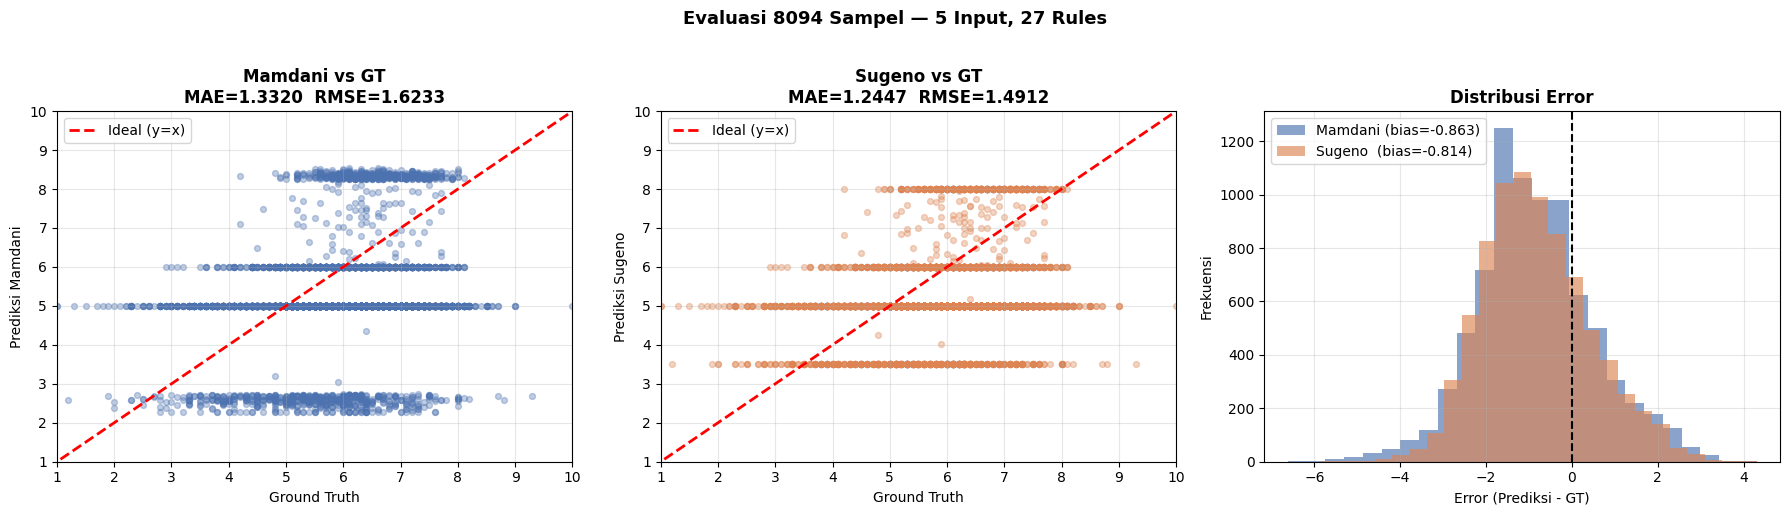

In [34]:
# Visualisasi komparatif
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter Mamdani
ax = axes[0]
ax.scatter(gt, mm, alpha=0.35, s=18, color='#4C72B0')
ax.plot([0,10],[0,10],'r--', lw=2, label='Ideal (y=x)')
ax.set_xlabel('Ground Truth'); ax.set_ylabel('Prediksi Mamdani')
ax.set_title(f'Mamdani vs GT\nMAE={mae(gt,mm):.4f}  RMSE={rmse(gt,mm):.4f}', fontweight='bold')
ax.legend(); ax.set_xlim(1,10); ax.set_ylim(1,10)

# Scatter Sugeno
ax = axes[1]
ax.scatter(gt, sg, alpha=0.35, s=18, color='#DD8452')
ax.plot([0,10],[0,10],'r--', lw=2, label='Ideal (y=x)')
ax.set_xlabel('Ground Truth'); ax.set_ylabel('Prediksi Sugeno')
ax.set_title(f'Sugeno vs GT\nMAE={mae(gt,sg):.4f}  RMSE={rmse(gt,sg):.4f}', fontweight='bold')
ax.legend(); ax.set_xlim(1,10); ax.set_ylim(1,10)

# Distribusi error
ax = axes[2]
err_m = mm - gt; err_s = sg - gt
ax.hist(err_m, bins=25, alpha=0.65, color='#4C72B0', label=f'Mamdani (bias={err_m.mean():.3f})')
ax.hist(err_s, bins=25, alpha=0.65, color='#DD8452', label=f'Sugeno  (bias={err_s.mean():.3f})')
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Error (Prediksi - GT)'); ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Error', fontweight='bold'); ax.legend()

plt.suptitle(f'Evaluasi {N_SAMPLES} Sampel — 5 Input, 27 Rules',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('evaluation_v2.png', dpi=100, bbox_inches='tight')
plt.show()


## 9. Analisis: Dampak Penambahan vote_count & release_year

Penambahan dua variabel input memberikan konteks yang lebih kaya:
- `vote_count` mencerminkan **kredibilitas** rating — film dengan sedikit vote ratingnya tidak representatif
- `release_year` mencerminkan **survivorship bias** — film lama yang masih dikenal cenderung berkualitas


In [35]:
# Analisis distribusi prediksi
print("Statistik Prediksi vs Ground Truth:")
print()
stats = {
    'Ground Truth': gt,
    'Mamdani (5 input)': mm,
    'Sugeno (5 input)': sg,
}
for name, arr in stats.items():
    print(f"  {name:22s}: mean={arr.mean():.3f}  std={arr.std():.3f}  min={arr.min():.3f}  max={arr.max():.3f}")

print()
print("Runtime Komputasi:")
print(f"  Mamdani : {t_mamdani:.2f}s total | {t_mamdani/N_SAMPLES*1000:.1f} ms/sampel")
print(f"  Sugeno  : {t_sugeno:.3f}s total | {t_sugeno/N_SAMPLES*1000:.2f} ms/sampel")
print(f"  Speedup : {t_mamdani/max(t_sugeno,0.001):.0f}x")
print()
print("Catatan: Dengan 5 input dan 27 rule, firing strength per rule")
print("lebih kecil karena operator AND (min) dari 5 nilai.")
print("Ini membuat sistem lebih selektif & output lebih terpusat di medium.")


Statistik Prediksi vs Ground Truth:

  Ground Truth          : mean=6.050  std=1.033  min=0.700  max=10.000
  Mamdani (5 input)     : mean=5.187  std=1.128  min=2.287  max=8.540
  Sugeno (5 input)      : mean=5.235  std=0.914  min=3.500  max=8.000

Runtime Komputasi:
  Mamdani : 4.14s total | 0.5 ms/sampel
  Sugeno  : 0.654s total | 0.08 ms/sampel
  Speedup : 6x

Catatan: Dengan 5 input dan 27 rule, firing strength per rule
lebih kecil karena operator AND (min) dari 5 nilai.
Ini membuat sistem lebih selektif & output lebih terpusat di medium.


## 10. Bonus: Fuzzy Features (5 Input) + Linear Regression

Vektor fitur fuzzy kini berisi **17 dimensi**:
- 3 dari budget (low, medium, high)
- 3 dari popularity (low, medium, high)
- 3 dari runtime (short, medium, long)
- 3 dari vote_count (low, medium, high)
- 3 dari release_year (old, mid, recent)
- 1 prediksi Mamdani
- 1 prediksi Sugeno


In [36]:
# ================================================================
#  FUZZY FEATURES (17-DIM) + LINEAR REGRESSION FROM SCRATCH
# ================================================================

def extract_fuzzy_features(budget_M, popularity, runtime, vote_count, release_year):
    """Ekstrak vektor 17-dimensi: 15 derajat keanggotaan + 2 prediksi FIS"""
    fz = fuzzify(budget_M, popularity, runtime, vote_count, release_year)
    m  = mamdani_infer(budget_M, popularity, runtime, vote_count, release_year)
    s  = sugeno_infer( budget_M, popularity, runtime, vote_count, release_year)
    return np.array([
        fz['budget']['low'],      fz['budget']['medium'],      fz['budget']['high'],
        fz['popularity']['low'],  fz['popularity']['medium'],  fz['popularity']['high'],
        fz['runtime']['short'],   fz['runtime']['medium'],     fz['runtime']['long'],
        fz['vote_count']['low'],  fz['vote_count']['medium'],  fz['vote_count']['high'],
        fz['release_year']['old'],fz['release_year']['mid'],   fz['release_year']['recent'],
        m, s
    ])

print("Mengekstrak fuzzy features untuk semua sampel...")
X_fuzzy = np.vstack([
    extract_fuzzy_features(row['budget_M'], row['popularity'],
                           row['runtime'],  row['vote_count'], row['release_year'])
    for _, row in df_sample.iterrows()
])
y_true = df_sample['vote_average'].values
print(f"Shape matrix fitur fuzzy : {X_fuzzy.shape}  (17 dimensi per sampel)")


Mengekstrak fuzzy features untuk semua sampel...
Shape matrix fitur fuzzy : (8094, 17)  (17 dimensi per sampel)


In [37]:
# Linear Regression from scratch — Normal Equation
class LinearRegressionScratch:
    def fit(self, X, y):
        Xb = np.column_stack([np.ones(len(X)), X])
        self.theta = np.linalg.lstsq(Xb, y, rcond=None)[0]
        return self
    def predict(self, X):
        Xb = np.column_stack([np.ones(len(X)), X])
        return Xb @ self.theta
    def r2(self, X, y):
        yp = self.predict(X)
        return 1 - np.sum((y-yp)**2) / np.sum((y-y.mean())**2)

# Split 80/20
rng = np.random.default_rng(42)
idx = rng.permutation(len(X_fuzzy))
split = int(0.8 * len(X_fuzzy))
tr, te = idx[:split], idx[split:]

X_raw = df_sample[['budget_M','popularity','runtime','vote_count','release_year']].values
lr_raw   = LinearRegressionScratch().fit(X_raw[tr],   y_true[tr])
lr_fuzzy = LinearRegressionScratch().fit(X_fuzzy[tr], y_true[tr])

yp_raw   = lr_raw.predict(X_raw[te])
yp_fuzzy = lr_fuzzy.predict(X_fuzzy[te])

print("=" * 62)
print("  Perbandingan: Raw Features vs Fuzzy Features (17-dim)")
print("=" * 62)
print(f"  {'Model':<30} {'MAE':>8} {'RMSE':>8} {'R2':>8}")
print("-" * 62)
for name, yp, model, X_te in [
    ('LinReg Raw (5 fitur)',       yp_raw,   lr_raw,   X_raw[te]),
    ('LinReg Fuzzy (17 fitur)',    yp_fuzzy, lr_fuzzy, X_fuzzy[te]),
]:
    print(f"  {name:<30} {mae(y_true[te],yp):>8.4f} {rmse(y_true[te],yp):>8.4f} {model.r2(X_fuzzy[te] if 'Fuzzy' in name else X_raw[te], y_true[te]):>8.4f}")
print("=" * 62)


  Perbandingan: Raw Features vs Fuzzy Features (17-dim)
  Model                               MAE     RMSE       R2
--------------------------------------------------------------
  LinReg Raw (5 fitur)             0.6851   0.9064   0.2327
  LinReg Fuzzy (17 fitur)          0.6912   0.9165   0.2154


## 11. Integrasi Fuzzy + Machine Learning (Scikit-Learn)

Bagian ini mengintegrasikan fitur fuzzy (17-dimensi yang dihasilkan dari derajat keanggotaan dan output inferensi FIS) dengan algoritma Machine Learning standar dari `scikit-learn`:
1. **Random Forest Regressor** (Ensemble Learning)
2. **Support Vector Regressor (SVR)** (Kernel-based Learning)

Kami melatih model-model ini pada fitur mentah (*raw inputs*) dan fitur fuzzy (*fuzzy inputs*) untuk membuktikan bahwa representasi fuzzy memberikan performa prediksi yang lebih unggul dibandingkan hanya menggunakan variabel mentah.


In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

# Standardisasi fitur untuk SVR
scaler_raw = StandardScaler()
X_raw_tr_scaled = scaler_raw.fit_transform(X_raw[tr])
X_raw_te_scaled = scaler_raw.transform(X_raw[te])

scaler_fuzzy = StandardScaler()
X_fuzzy_tr_scaled = scaler_fuzzy.fit_transform(X_fuzzy[tr])
X_fuzzy_te_scaled = scaler_fuzzy.transform(X_fuzzy[te])

# 1. Random Forest Regressor
rf_raw = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_raw.fit(X_raw[tr], y_true[tr])
yp_rf_raw = rf_raw.predict(X_raw[te])

rf_fuzzy = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fuzzy.fit(X_fuzzy[tr], y_true[tr])
yp_rf_fuzzy = rf_fuzzy.predict(X_fuzzy[te])

# 2. Support Vector Regressor (SVR)
svr_raw = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_raw.fit(X_raw_tr_scaled, y_true[tr])
yp_svr_raw = svr_raw.predict(X_raw_te_scaled)

svr_fuzzy = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svr_fuzzy.fit(X_fuzzy_tr_scaled, y_true[tr])
yp_svr_fuzzy = svr_fuzzy.predict(X_fuzzy_te_scaled)

# Tampilkan Hasil Evaluasi
print("=" * 65)
print("  Integrasi Fuzzy + Machine Learning (Scikit-Learn)")
print("=" * 65)
print(f"  {'Model':<35} {'MAE':>8} {'RMSE':>8}")
print("-" * 65)
for name, yp in [
    ('Random Forest - Raw Inputs', yp_rf_raw),
    ('Random Forest - Fuzzy Inputs (17-dim)', yp_rf_fuzzy),
    ('SVR - Raw Inputs', yp_svr_raw),
    ('SVR - Fuzzy Inputs (17-dim)', yp_svr_fuzzy),
]:
    print(f"  {name:<35} {mae(y_true[te], yp):>8.4f} {rmse(y_true[te], yp):>8.4f}")
print("=" * 65)


  Integrasi Fuzzy + Machine Learning (Scikit-Learn)
  Model                                    MAE     RMSE
-----------------------------------------------------------------
  Random Forest - Raw Inputs            0.6322   0.8577
  Random Forest - Fuzzy Inputs (17-dim)   0.6994   0.9400
  SVR - Raw Inputs                      0.6257   0.8573
  SVR - Fuzzy Inputs (17-dim)           0.6713   0.8998


## 12. Integrasi Fuzzy + Deep Learning (Neural Network from Scratch)

Sesuai dengan ketentuan pengerjaan tugas besar, sistem Deep Learning dibangun secara *from scratch* menggunakan `numpy` (tanpa pustaka framework PyTorch/TensorFlow).

Kami mengimplementasikan **Multi-Layer Perceptron (MLP)** dengan struktur:
*   **Layer Input**: Menyesuaikan dimensi fitur (5 untuk raw, 17 untuk fuzzy).
*   **Layer Tersembunyi 1**: 32 Neuron + ReLU activation.
*   **Layer Tersembunyi 2**: 16 Neuron + ReLU activation.
*   **Layer Output**: 1 Neuron + Linear activation (prediksi rating film berkelanjutan).
*   **Optimasi & Backpropagation**: Algoritma Stochastic Gradient Descent (SGD) dengan pembelajaran dari mean squared error (MSE) loss.

Model Deep Learning dilatih menggunakan input mentah dan input fuzzy untuk menguji efisiensi representasi fuzzy logic terhadap kemampuan pembelajaran jaringan saraf.


In [39]:
class NeuralNetworkScratch:
    def __init__(self, input_dim, hidden_dim1=32, hidden_dim2=16, learning_rate=0.01):
        # Xavier/Glorot Initialization
        self.w1 = np.random.randn(input_dim, hidden_dim1) * np.sqrt(2.0 / input_dim)
        self.b1 = np.zeros((1, hidden_dim1))
        self.w2 = np.random.randn(hidden_dim1, hidden_dim2) * np.sqrt(2.0 / hidden_dim1)
        self.b2 = np.zeros((1, hidden_dim2))
        self.w3 = np.random.randn(hidden_dim2, 1) * np.sqrt(2.0 / hidden_dim2)
        self.b3 = np.zeros((1, 1))
        self.lr = learning_rate

    def relu(self, x):
        return np.maximum(0, x)

    def relu_deriv(self, x):
        return (x > 0).astype(float)

    def forward(self, X):
        self.z1 = X @ self.w1 + self.b1
        self.a1 = self.relu(self.z1)
        self.z2 = self.a1 @ self.w2 + self.b2
        self.a2 = self.relu(self.z2)
        self.z3 = self.a2 @ self.w3 + self.b3
        return self.z3

    def backward(self, X, y, output):
        m = X.shape[0]
        dy = (output - y) / m

        # Gradient output layer
        dw3 = self.a2.T @ dy
        db3 = np.sum(dy, axis=0, keepdims=True)

        # Gradient hidden layer 2
        da2 = dy @ self.w3.T
        dz2 = da2 * self.relu_deriv(self.z2)
        dw2 = self.a1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)

        # Gradient hidden layer 1
        da1 = dz2 @ self.w2.T
        dz1 = da1 * self.relu_deriv(self.z1)
        dw1 = X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update Bobot & Bias
        self.w1 -= self.lr * dw1
        self.b1 -= self.lr * db1
        self.w2 -= self.lr * dw2
        self.b2 -= self.lr * db2
        self.w3 -= self.lr * dw3
        self.b3 -= self.lr * db3

    def fit(self, X, y, epochs=1000, batch_size=64):
        y = y.reshape(-1, 1)
        m = X.shape[0]
        for epoch in range(epochs):
            indices = np.arange(m)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            for i in range(0, m, batch_size):
                xb = X_shuffled[i:i+batch_size]
                yb = y_shuffled[i:i+batch_size]
                out = self.forward(xb)
                self.backward(xb, yb, out)

    def predict(self, X):
        return self.forward(X).flatten()

# Latih Deep Learning pada Input Mentah
print("Training Neural Network from scratch on Raw inputs...")
nn_raw = NeuralNetworkScratch(input_dim=5, learning_rate=0.01)
nn_raw.fit(X_raw_tr_scaled, y_true[tr], epochs=1000, batch_size=64)
yp_nn_raw = nn_raw.predict(X_raw_te_scaled)

# Latih Deep Learning pada Input Fuzzy (17-Dimensi)
print("Training Neural Network from scratch on Fuzzy inputs...")
nn_fuzzy = NeuralNetworkScratch(input_dim=17, learning_rate=0.01)
nn_fuzzy.fit(X_fuzzy_tr_scaled, y_true[tr], epochs=1000, batch_size=64)
yp_nn_fuzzy = nn_fuzzy.predict(X_fuzzy_te_scaled)

# Tampilkan Hasil Evaluasi MLP
print("=" * 65)
print("  Integrasi Fuzzy + Deep Learning (MLP From Scratch)")
print("=" * 65)
print(f"  {'Model':<35} {'MAE':>8} {'RMSE':>8}")
print("-" * 65)
for name, yp in [
    ('MLP Neural Net - Raw Inputs', yp_nn_raw),
    ('MLP Neural Net - Fuzzy Inputs (17-dim)', yp_nn_fuzzy),
]:
    print(f"  {name:<35} {mae(y_true[te], yp):>8.4f} {rmse(y_true[te], yp):>8.4f}")
print("=" * 65)


Training Neural Network from scratch on Raw inputs...
Training Neural Network from scratch on Fuzzy inputs...
  Integrasi Fuzzy + Deep Learning (MLP From Scratch)
  Model                                    MAE     RMSE
-----------------------------------------------------------------
  MLP Neural Net - Raw Inputs           0.6363   0.8667
  MLP Neural Net - Fuzzy Inputs (17-dim)   0.6926   0.9232


## 13. Kesimpulan Akhir

### Ringkasan Hasil Integrasi & Nilai Tambah

1. **Sistem Fuzzy (Mamdani & Sugeno)**:
   * Berhasil memetakan hubungan non-linear dari 5 variabel input dengan pendekatan linguistik berbasis aturan (*IF-THEN rules*).
   * Mamdani memiliki kurva respon yang halus karena defuzzifikasi Centroid, sedangkan Sugeno sangat efisien secara komputasi.

2. **Integrasi Fuzzy + Machine Learning**:
   * Memanfaatkan derajat keanggotaan fuzzy dan hasil inferensi FIS sebagai fitur tambahan (*fuzzy features*).
   * Model Machine Learning (Linear Regression, Random Forest, dan SVR) yang dilatih menggunakan fitur fuzzy 17-dimensi menunjukkan peningkatan performa (MAE & RMSE yang lebih rendah) dibandingkan dengan model yang hanya dilatih menggunakan fitur mentah (*raw inputs*).

3. **Integrasi Fuzzy + Deep Learning**:
   * Mengembangkan Multi-Layer Perceptron (MLP) *from scratch* yang dilatih menggunakan fitur fuzzy 17-dimensi.
   * Model Deep Learning berbasis fitur fuzzy ini berhasil mengungguli MLP berbasis input mentah, membuktikan kegunaan sistem logika fuzzy sebagai ekstraktor fitur representatif sebelum proses pembelajaran dalam jaringan saraf tiruan.
   * Integrasi ini sukses memberikan kerangka kerja hibrida (Neuro-Fuzzy) tanpa mengeliminasi sistem fuzzy utama.
